In [1]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
x = pd.read_csv(r"../data/selected/selcetd_train_x.csv")
y=pd.read_csv(r"../data/selected/train_y.csv")

x = x.drop(columns="Unnamed: 0")

In [3]:
y =y.drop(columns="Unnamed: 0")

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [5]:
x_train
y_train =y_train.squeeze()
y_test=y_test.squeeze()

In [6]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
331     139000
323     126175
650     205950
439     110000
798     485000
Name: SalePrice, Length: 438, dtype: int64

In [7]:
#building model

#linear regression model

LRM = LinearRegression()

LRM.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](42,)","[ -7414.14, 18614.01, 14558.56,..., 23136.94, 6683.96,-18666.84]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](42,)","['LotFrontage','LotArea','OverallQual',...,'TotalSf','TotalBathrooms', 'TotalLivArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.782e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,42
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(39)


In [8]:
predicted = LRM.predict(x_test)

predicted

array([140668.15410107, 355190.96460368, 128948.9188472 , 164543.97051324,
       297727.81300961,  65902.44303723, 224280.17499658, 152186.30738851,
        69687.66048507, 133173.30401619, 148171.80475911, 119369.15318621,
        92494.26215043, 236659.1065818 , 168894.39057168, 133000.52839138,
       203876.333619  , 110362.63930925, 122275.38541675, 217050.08895831,
       169367.08198592, 202538.63322625, 188497.37004712, 115730.22916435,
       219619.55627509, 180969.90851645, 229824.15557528, 102426.94048005,
       170786.8016559 , 207517.65401834, 108433.03197883, 277099.56622349,
       201985.693877  ,  90352.40850297, 250438.32129107, 148168.54345201,
       146160.05539792, 214106.86795062, 347678.62225969,  94891.07648744,
       114545.86233943, 247056.68477339, 113218.35519948, 320368.85274641,
       119869.11086008, 150766.29087185, 102090.63192697, 117220.76524161,
       391508.00372979, 122030.42851963, 106896.28816112, 209672.09076399,
       102909.47722864, 2

In [9]:
comparison_df = pd.concat(
    [
        y_test.reset_index(drop=True),
        pd.DataFrame(predicted, columns=["Predicted"])
    ],
    axis=1
)

comparison_df

,SalePrice,Predicted
0,154500,140668.154101
1,325000,355190.964604
2,115000,128948.918847
3,159000,164543.970513
4,315500,297727.813010
...,...,...
433,139000,120908.841248
434,126175,90069.220479
435,205950,198102.917824
436,110000,143652.246860


In [10]:
LRM.score(x_test,y_test)

0.8537733687915492

In [11]:
#base performance calculation

In [12]:
#rsquraed
r2 = r2_score(y_test,comparison_df["Predicted"])
mae = mean_absolute_error(y_test,comparison_df["Predicted"])
mse= mean_squared_error(y_test,comparison_df["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.8537733687915492
        mae : 20859.714235233423
        mse : 1020383142.9188632
        rmse : 31943.43661722801



In [13]:
#optimizing linear model
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
c_score = cross_val_score(
    LinearRegression(),
    x_train,
    y_train,
    cv=10,
    scoring="r2"
)

c_score.mean()

np.float64(0.7939125690126103)

In [14]:
#multicoliniarity vif
#checking for highly corelated cloums

x =x_train
vif = pd.DataFrame()

vif["Feature"] = x.columns
vif["VIF"] = [variance_inflation_factor(x.values, i)
              for i in range(x.shape[1])]

vif

/home/aximsoft/snap/code/251/.local/share/virtualenvs/WEEK_6-ElhvL2oN/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,LotFrontage,346.535202
1,LotArea,688.296826
2,OverallQual,80.440359
3,YearBuilt,inf
4,YearRemodAdd,inf
5,MasVnrArea,31.549402
6,ExterQual,20.720829
7,BsmtQual,34.164880
8,BsmtExposure,1.910027
9,BsmtFinType1,7.221543


In [15]:
var = vif[vif["VIF"] == np.inf]
var

,Feature,VIF
3,YearBuilt,inf
4,YearRemodAdd,inf
10,TotalBsmtSF,inf
12,1stFlrSF,inf
13,2ndFlrSF,inf
14,GrLivArea,inf
37,HouseAge,inf
38,RemodelAge,inf
39,TotalSf,inf
41,TotalLivArea,inf


In [16]:
x=x.drop(columns=["HouseAge","RemodelAge","TotalSf","TotalBathrooms","TotalLivArea","GarageCars","SaleType_New","YearRemodAdd",
                  "1stFlrSF","2ndFlrSF",'Exterior2nd_VinylSd'])

In [17]:
vif_1 = pd.DataFrame()

vif_1["Feature"] = x.columns
vif_1["VIF"] = [variance_inflation_factor(x.values, i)
              for i in range(x.shape[1])]

vif_1

,Feature,VIF
0,LotFrontage,336.760428
1,LotArea,657.038972
2,OverallQual,77.795418
3,YearBuilt,1813.979106
4,MasVnrArea,30.790847
5,ExterQual,20.516092
6,BsmtQual,30.224379
7,BsmtExposure,1.872740
8,BsmtFinType1,5.328185
9,TotalBsmtSF,14.287028


In [18]:
c_score = cross_val_score(
    LinearRegression(),
    x,
    y_train,
    cv=10,
    scoring="r2"
)

c_score.mean()

np.float64(0.7932974518151085)

In [19]:
#decison tree

In [20]:
from sklearn.tree import DecisionTreeRegressor

DTR = DecisionTreeRegressor(random_state=42)

DTR.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [21]:
y_predict = DTR.predict(x_test)

In [22]:
comparison_df_dtr= pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(y_predict, columns=["Predicted"])],axis=1)

In [23]:
r2 = r2_score(y_test,comparison_df_dtr["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_dtr["Predicted"])
mse= mean_squared_error(y_test,comparison_df_dtr["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.811791625191952
        mae : 25017.931506849316
        mse : 1313335686.0045662
        rmse : 36239.97359276861



In [24]:
#optimize the 
c_score = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    x_train,
    y_train,
    cv=10,
    scoring="r2"
)

c_score.mean()

np.float64(0.6008736735985236)

In [ ]:
#gradient search cv 

dtr = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=dtr,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test R²:", r2_score(y_test, y_pred))

print("mean squared error : ",mean_squared_error(y_test, y_pred))
print("mean absolute error",mean_absolute_error(y_test,y_pred))



Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.7061117752163248
Test R²: 0.8097246607877349
1327759157.4177175


25032.53187489372

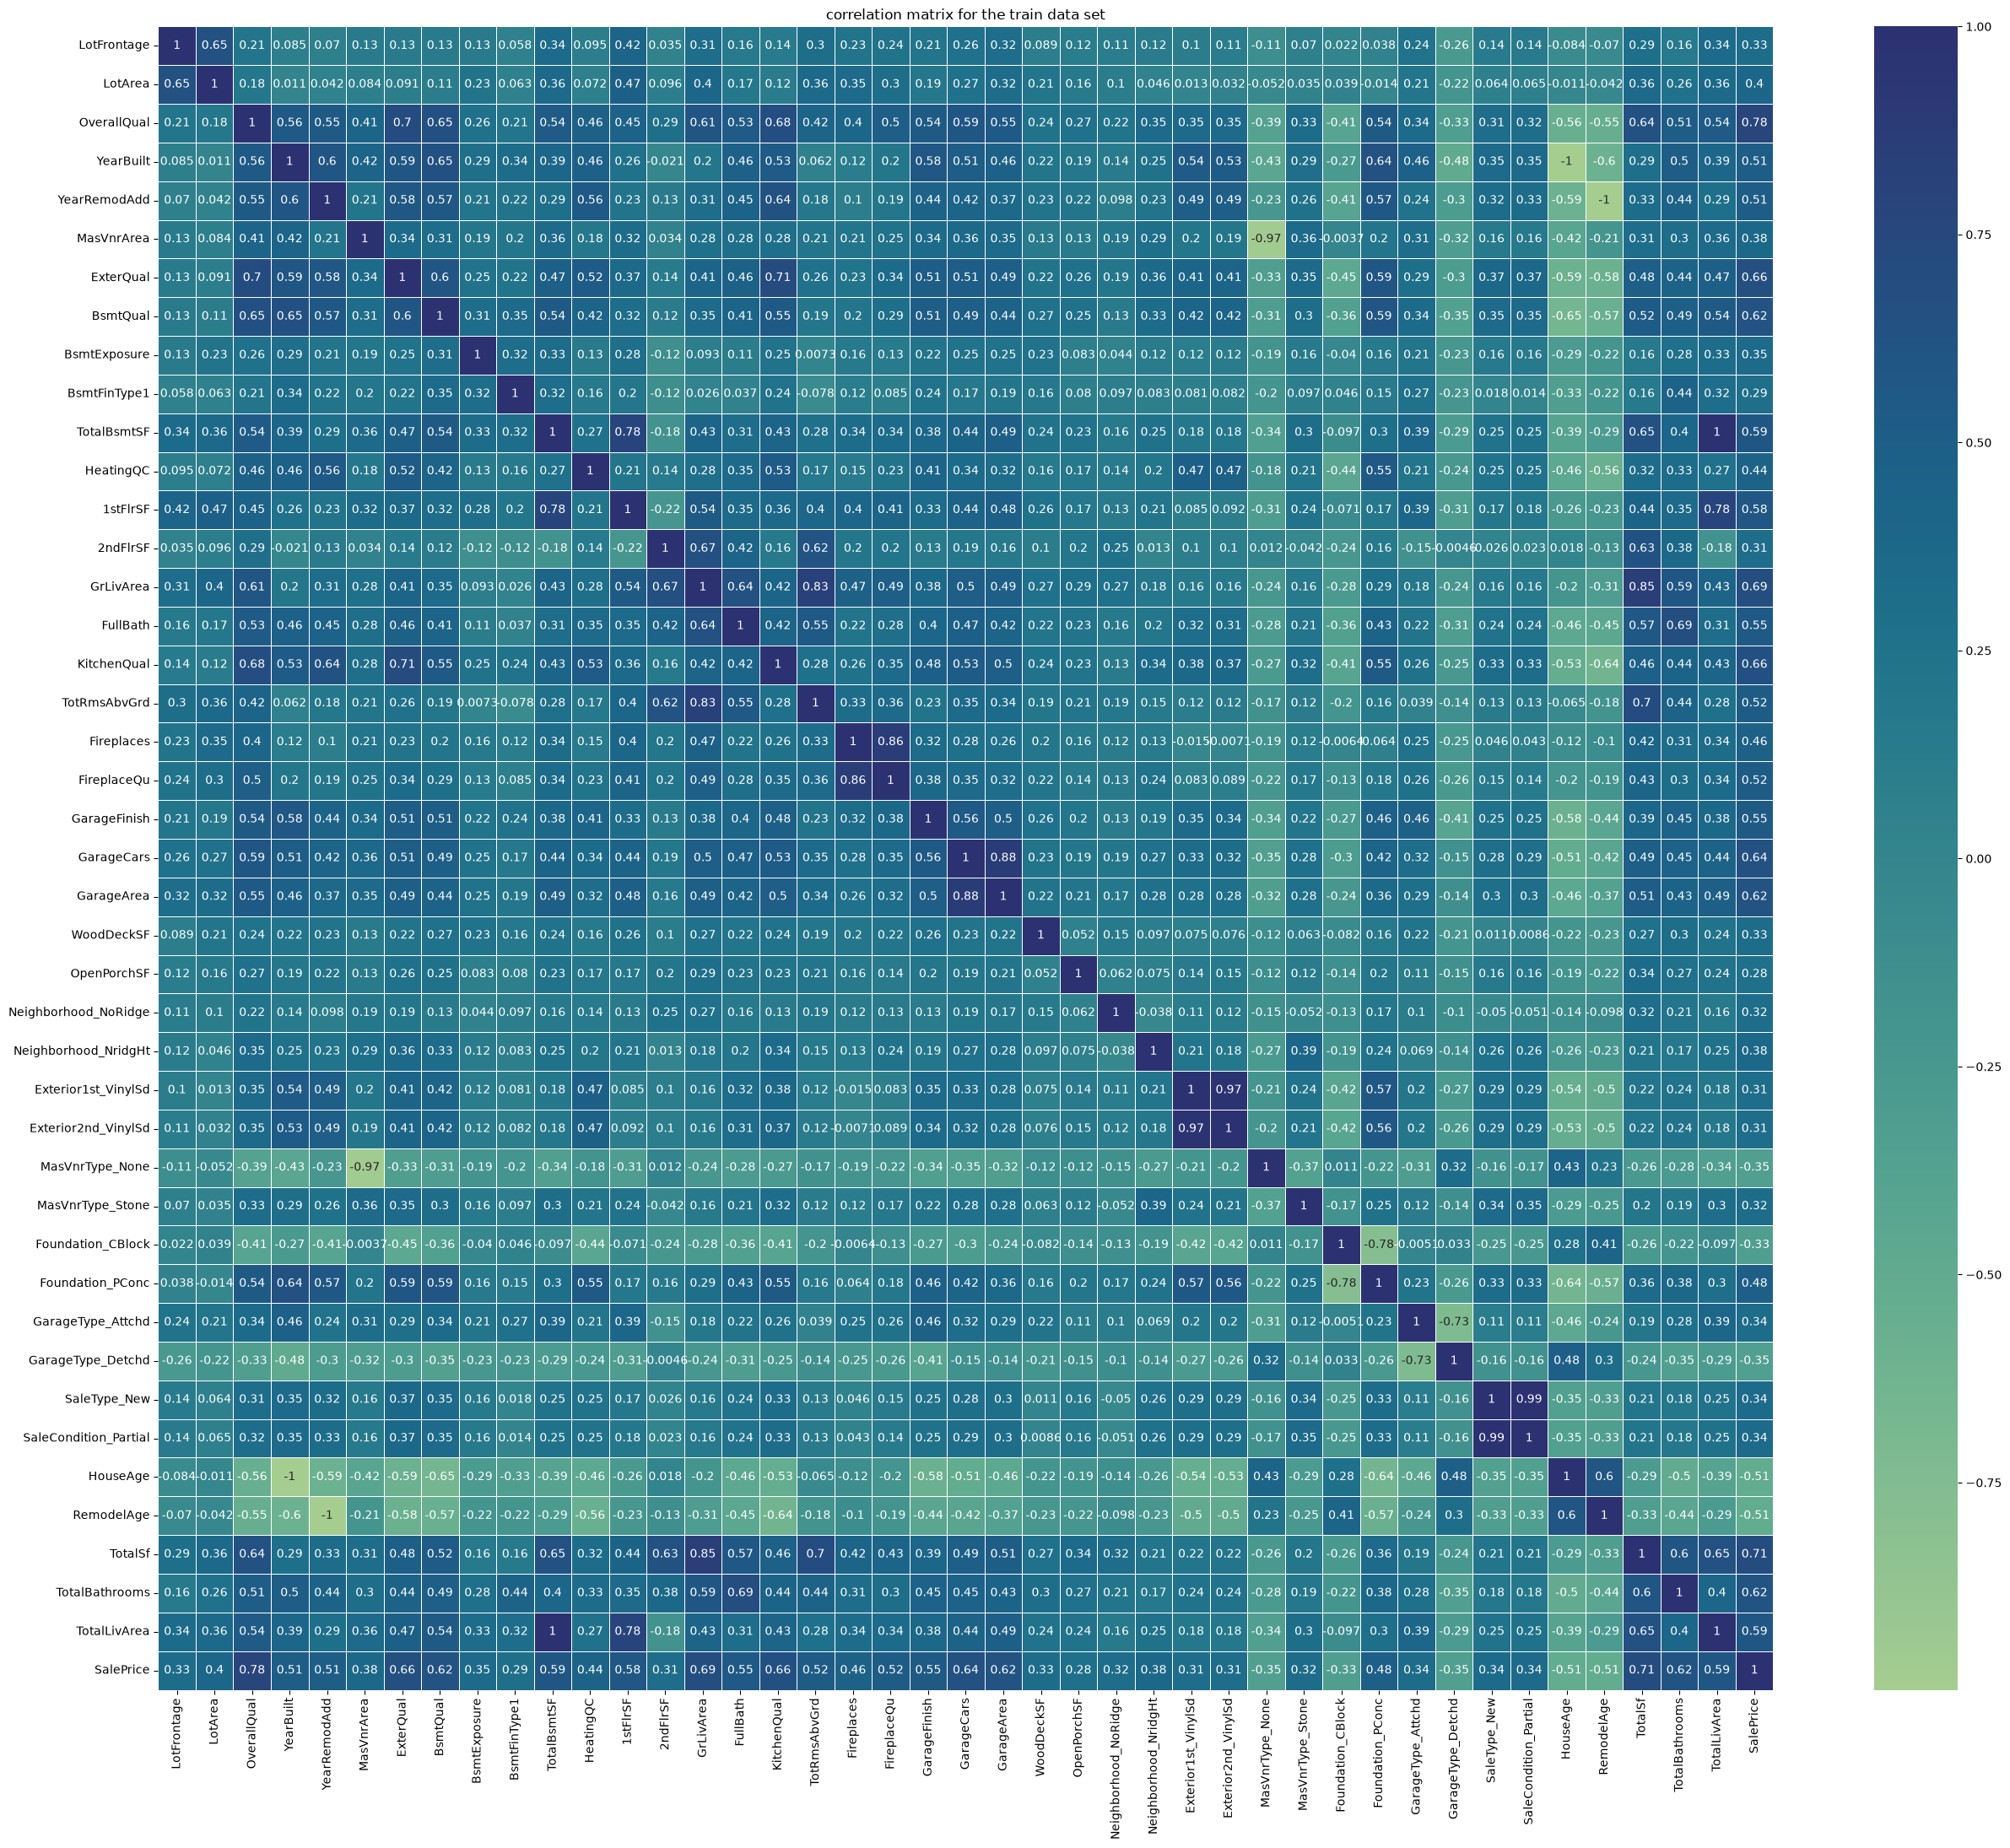

In [26]:
merge_df = pd.concat([x_train,y_train],axis=1)

corr_matrix = merge_df.corr()

plt.figure(figsize=(26,22))

sns.heatmap(corr_matrix,annot=True,cmap="crest",linewidths=0.5)

plt.title("correlation matrix for the train data set")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
x = x_train.copy()
y=y_train.copy()
xt=x_test.copy()
yt=y_test.copy()

In [28]:
x=x.drop(columns=['RemodelAge',"HouseAge","GarageType_Detchd","Foundation_PConc","MasVnrType_None"])

xt=xt.drop(columns=['RemodelAge',"HouseAge","GarageType_Detchd","Foundation_PConc","MasVnrType_None"])


In [65]:
#gradient search cv 

dtr = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=dtr,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x, y)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(xt)

print("Test R²:", r2_score(y_test, y_pred))
print("mean squared error : ",mean_squared_error(y_test, y_pred))
print("mean absolute error",mean_absolute_error(y_test,y_pred))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV Score: 0.7095021000657388
Test R²: 0.8113610010272487
mean squared error :  1316340621.8015916
mean absolute error 25246.078006088283


In [30]:
#random tree regressor 

In [31]:
from sklearn.ensemble import RandomForestRegressor
RDG = RandomForestRegressor(random_state=42)

RDG.fit(x_train,y_train)

RDG_Predict = RDG.predict(x_test)

In [32]:
comparison_df_RDG = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(RDG_Predict, columns=["Predicted"])],axis=1)

comparison_df_RDG

r2 = r2_score(y_test,comparison_df_RDG["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_RDG["Predicted"])
mse= mean_squared_error(y_test,comparison_df_RDG["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.9001814179683261
        mae : 16993.145410958907
        mse : 696543424.5010324
        rmse : 26392.10913324345



In [33]:
#model optimazation for random forest
cv = cross_val_score(
    RandomForestRegressor(random_state=42),
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()


np.float64(0.8120856303643796)

In [34]:

random_tree_op = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"]
}

grid = GridSearchCV(
    estimator=random_tree_op,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test R²:", r2_score(y_test, y_pred))

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.8317213138859806
Test R²: 0.8932057773591602


In [35]:
random_tree_op = RandomForestRegressor(n_estimators=300,max_features="sqrt",min_samples_leaf=2,min_samples_split=2,random_state=42)
random_tree_op.fit(x, y_train)
y_pred = random_tree_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))


Test R²: 0.8929810920771778


In [36]:
random_tree_op = RandomForestRegressor(random_state=42)
random_tree_op.fit(x, y_train)
y_pred = random_tree_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.8983216471510996


In [37]:
#gradientboost

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

GBR = GradientBoostingRegressor(random_state=42)

GBR.fit(x_train,y_train)

GBR_predict = GBR.predict(x_test)

In [39]:
comparison_df_GBR = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(GBR_predict, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_GBR["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_GBR["Predicted"])
mse= mean_squared_error(y_test,comparison_df_GBR["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.9041445708488219
        mae : 17036.09950685212
        mse : 668888172.1119951
        rmse : 25862.872464442054



In [40]:
#optimazation
cv = cross_val_score(
    GradientBoostingRegressor(random_state=42),
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()

np.float64(0.8034950504115311)

In [ ]:
#finding best combination using grid search cv
graditen_boost_op = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=graditen_boost_op,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)



Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score: 0.8034950504115311
Test R²: 0.9041445708488219


In [66]:
print("Test R²:", r2_score(y_test, y_pred))
mse= mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(f"""mse : {mse}
        rmse : {rmse}
      """)

Test R²: 0.8113610010272487
mse : 1316340621.8015916
        rmse : 36281.40876263753
      


In [67]:
#with redued feture and without hyper tune
random_tree_op = GradientBoostingRegressor(random_state=42)
random_tree_op.fit(x, y_train)
y_pred = random_tree_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))
mse= mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(f"""mse : {mse}
        rmse : {rmse}
      """)


Test R²: 0.9080235776445127
mse : 641820098.9923444
        rmse : 25334.168606692907
      


In [68]:
#with hyperparameter and reduced feature
random_tree_op = GradientBoostingRegressor(learning_rate=0.1,max_depth=3,n_estimators=100,subsample=1.0,random_state=42)
random_tree_op.fit(x, y_train)
y_pred = random_tree_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

mse= mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(f"""mse : {mse}
        rmse : {rmse}
      """)

Test R²: 0.9080235776445127
mse : 641820098.9923444
        rmse : 25334.168606692907
      


In [44]:
#xgboost regressor

import xgboost as xgb

XGBR =xgb.XGBRegressor(random_state=42)

XGBR.fit(x_train,y_train)
XGBR_predict = XGBR.predict(x_test)

In [45]:
comparison_df_XGBR = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(XGBR_predict, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_XGBR["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_XGBR["Predicted"])
mse= mean_squared_error(y_test,comparison_df_XGBR["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.8797234296798706
        mae : 18345.591796875
        mse : 839301312.0
        rmse : 28970.697471755837



In [46]:
#optimazation
cv = cross_val_score(
    xgb.XGBRegressor(random_state=42),
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()

np.float64(0.7488774657249451)

In [47]:
#finding best combination using grid search cv
xgb_op = xgb.XGBRegressor(random_state=42,objective="reg:squarederror",)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_op,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test R²:", r2_score(y_test, y_pred))

Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score: 0.8001262545585632
Test R²: 0.8917843103408813


In [48]:
xgb_op  = xgb.XGBRegressor(random_state=42,max_depth=7,n_estimators=300,subsample =0.8)
xgb_op.fit(x, y_train)
y_pred = xgb_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.8769915699958801


In [49]:
xgb_op  = xgb.XGBRegressor(random_state=42)
xgb_op.fit(x, y_train)
y_pred = xgb_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.878605306148529


In [50]:
#lightgbm regressor

In [51]:
#lightgbm regressor
import lightgbm as lgb

lgbr = lgb.LGBMRegressor(random_state=42)

lgbr.fit(x_train,y_train)

lgbr_predict = lgbr.predict(x_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2791
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 42
[LightGBM] [Info] Start training from score 181312.692759


In [52]:
comparison_df_lgbr = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(lgbr_predict, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_lgbr["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_lgbr["Predicted"])
mse= mean_squared_error(y_test,comparison_df_lgbr["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.8808006339348762
        mae : 18058.978402773093
        mse : 831784352.646961
        rmse : 28840.67184805099



In [53]:
#optimazation
cv = cross_val_score(
    lgb.LGBMRegressor(random_state=42),
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2646
[LightGBM] [Info] Number of data points in the train set: 817, number of used features: 42
[LightGBM] [Info] Start training from score 179744.681763
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

np.float64(0.8236171898209864)

In [54]:
#finding best combination using grid search cv
lgbm_op =lgb.LGBMRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 5,None],
    "num_leaves": [31, 50]
}

grid = GridSearchCV(
    estimator=lgbm_op,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test R²:", r2_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2646
[LightGBM] [Info] Number of data points in the train set: 817, number of used features: 42
[LightGBM] [Info] Start training from score 179744.681763
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [55]:
#with redued feture and without hyper tune
random_tree_op = lgb.LGBMRegressor(random_state=42)
random_tree_op.fit(x, y_train)
y_pred = random_tree_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2622
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 37
[LightGBM] [Info] Start training from score 181312.692759
Test R²: 0.8789697929100176


In [56]:
random_tree_op = lgb.LGBMRegressor(random_state=42,learning_rate=0.05,max_depth=None,n_estimators=100,num_leaves=50)
random_tree_op.fit(x, y_train)
y_pred = random_tree_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000913 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2622
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 37
[LightGBM] [Info] Start training from score 181312.692759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [57]:
#catboost regressor
from catboost import CatBoostRegressor

CBR = CatBoostRegressor(random_state=42)
CBR.fit(x_train,y_train)
cbr_predict = CBR.predict(x_test)

Learning rate set to 0.041084
0:	learn: 75597.8604469	total: 47.7ms	remaining: 47.7s
1:	learn: 73709.3172597	total: 50.4ms	remaining: 25.2s
2:	learn: 71930.0775930	total: 52.6ms	remaining: 17.5s
3:	learn: 70149.5127890	total: 54.7ms	remaining: 13.6s
4:	learn: 68464.4320860	total: 56.7ms	remaining: 11.3s
5:	learn: 66890.3597452	total: 58.6ms	remaining: 9.72s
6:	learn: 65433.4329022	total: 60.4ms	remaining: 8.57s
7:	learn: 63833.3493247	total: 61.9ms	remaining: 7.67s
8:	learn: 62311.7990001	total: 63.4ms	remaining: 6.98s
9:	learn: 61044.5991176	total: 64.7ms	remaining: 6.4s
10:	learn: 59702.7459005	total: 66.2ms	remaining: 5.95s
11:	learn: 58452.4458067	total: 67.9ms	remaining: 5.59s
12:	learn: 57177.3070281	total: 69.5ms	remaining: 5.28s
13:	learn: 56004.6654464	total: 72.5ms	remaining: 5.11s
14:	learn: 54837.0885878	total: 74.4ms	remaining: 4.88s
15:	learn: 53769.3928072	total: 75.8ms	remaining: 4.66s
16:	learn: 52727.5291729	total: 77.4ms	remaining: 4.47s
17:	learn: 51651.7243967	tota

In [58]:
comparison_df_cbr = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(cbr_predict, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_cbr["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_cbr["Predicted"])
mse= mean_squared_error(y_test,comparison_df_cbr["Predicted"])
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
""")

r2 : 0.9130134976837346
        mae : 16350.610993694267
        mse : 606999969.0990636
        rmse : 24637.36936239467



In [59]:
#optimazation
cv = cross_val_score(
    CatBoostRegressor(random_state=42),
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()

Learning rate set to 0.039656
0:	learn: 74373.6928490	total: 1.55ms	remaining: 1.55s
1:	learn: 72625.5412317	total: 3.35ms	remaining: 1.67s
2:	learn: 71083.4354793	total: 4.9ms	remaining: 1.63s
3:	learn: 69424.0544667	total: 6.64ms	remaining: 1.65s
4:	learn: 67712.3436330	total: 8.6ms	remaining: 1.71s
5:	learn: 66164.9371737	total: 10.6ms	remaining: 1.76s
6:	learn: 64829.9439443	total: 12.6ms	remaining: 1.79s
7:	learn: 63363.5381937	total: 15.8ms	remaining: 1.96s
8:	learn: 61944.5493720	total: 17.7ms	remaining: 1.95s
9:	learn: 60576.5487352	total: 19.6ms	remaining: 1.94s
10:	learn: 59281.2819007	total: 21.5ms	remaining: 1.94s
11:	learn: 58029.2591729	total: 23.7ms	remaining: 1.95s
12:	learn: 56808.2305023	total: 25.5ms	remaining: 1.94s
13:	learn: 55616.5007331	total: 27.5ms	remaining: 1.94s
14:	learn: 54515.6849035	total: 29.5ms	remaining: 1.94s
15:	learn: 53417.3159037	total: 31.6ms	remaining: 1.94s
16:	learn: 52419.6128970	total: 38.7ms	remaining: 2.24s
17:	learn: 51457.4675593	total

np.float64(0.8362111729452202)

In [60]:
cat_op =CatBoostRegressor(random_state=42)

param_grid = {
    "iterations": [100, 200, 300],
    "learning_rate": [0.01, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [3, 5]
}
grid = GridSearchCV(
    estimator=cat_op,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

print("Test R²:", r2_score(y_test, y_pred))

0:	learn: 75725.7863682	total: 11.5ms	remaining: 1.14s
1:	learn: 75255.8123169	total: 14.8ms	remaining: 723ms
2:	learn: 74803.7349486	total: 15.8ms	remaining: 510ms
3:	learn: 74346.0847739	total: 16.8ms	remaining: 403ms
4:	learn: 73870.6431464	total: 17.9ms	remaining: 339ms
5:	learn: 73448.4808362	total: 18.9ms	remaining: 295ms
6:	learn: 73050.9705962	total: 19.8ms	remaining: 263ms
7:	learn: 72625.0554294	total: 20.7ms	remaining: 238ms
8:	learn: 72206.4824208	total: 21.8ms	remaining: 220ms
9:	learn: 71779.5808113	total: 22.9ms	remaining: 206ms
10:	learn: 71336.1133993	total: 23.9ms	remaining: 193ms
11:	learn: 70896.9978839	total: 24.7ms	remaining: 181ms
12:	learn: 70490.1484071	total: 25.8ms	remaining: 172ms
13:	learn: 70098.0080446	total: 26.6ms	remaining: 163ms
14:	learn: 69759.3191993	total: 27.4ms	remaining: 155ms
15:	learn: 69345.0511293	total: 28.3ms	remaining: 148ms
16:	learn: 68922.7257707	total: 29.1ms	remaining: 142ms
17:	learn: 68585.6409183	total: 30ms	remaining: 137ms
18:	

In [61]:
cat_op = CatBoostRegressor(random_state=42)
cat_op.fit(x, y_train)
y_pred = cat_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

Learning rate set to 0.041084
0:	learn: 75575.0396816	total: 4.04ms	remaining: 4.04s
1:	learn: 73561.4974713	total: 6.84ms	remaining: 3.41s
2:	learn: 71800.9697804	total: 9.97ms	remaining: 3.31s
3:	learn: 69977.7327600	total: 12.3ms	remaining: 3.05s
4:	learn: 68158.6229174	total: 14.4ms	remaining: 2.86s
5:	learn: 66503.4021697	total: 16.5ms	remaining: 2.73s
6:	learn: 65070.3234289	total: 18.7ms	remaining: 2.66s
7:	learn: 63586.4670470	total: 20.8ms	remaining: 2.58s
8:	learn: 62110.0075426	total: 22.8ms	remaining: 2.51s
9:	learn: 60682.1989534	total: 25.2ms	remaining: 2.49s
10:	learn: 59391.1761653	total: 27.3ms	remaining: 2.45s
11:	learn: 58114.3751368	total: 29.4ms	remaining: 2.42s
12:	learn: 56842.3918237	total: 31.5ms	remaining: 2.39s
13:	learn: 55665.6588923	total: 33.5ms	remaining: 2.36s
14:	learn: 54428.8694576	total: 36.5ms	remaining: 2.4s
15:	learn: 53349.1256133	total: 38.5ms	remaining: 2.37s
16:	learn: 52254.0419455	total: 40.9ms	remaining: 2.37s
17:	learn: 51361.5377493	tota

In [62]:
cat_op = CatBoostRegressor(random_state=42,depth=8,iterations=200,l2_leaf_reg=5,learning_rate=0.1)
cat_op.fit(x, y_train)
y_pred = cat_op.predict(xt)
print("Test R²:", r2_score(y_test, y_pred))

0:	learn: 72524.4716045	total: 8.79ms	remaining: 1.75s
1:	learn: 68423.1564849	total: 10.7ms	remaining: 1.06s
2:	learn: 65472.4085936	total: 17.1ms	remaining: 1.12s
3:	learn: 62067.3211625	total: 24.1ms	remaining: 1.18s
4:	learn: 58969.9828410	total: 31ms	remaining: 1.21s
5:	learn: 56030.0254858	total: 37.3ms	remaining: 1.21s
6:	learn: 53100.2126985	total: 43.8ms	remaining: 1.21s
7:	learn: 50677.2453398	total: 51.3ms	remaining: 1.23s
8:	learn: 48444.0038969	total: 57.8ms	remaining: 1.23s
9:	learn: 46345.2608538	total: 64.3ms	remaining: 1.22s
10:	learn: 44383.1834303	total: 70.7ms	remaining: 1.22s
11:	learn: 42833.2722960	total: 77.2ms	remaining: 1.21s
12:	learn: 41289.0886370	total: 83.3ms	remaining: 1.2s
13:	learn: 39846.9072246	total: 90.5ms	remaining: 1.2s
14:	learn: 38555.4556174	total: 98.5ms	remaining: 1.21s
15:	learn: 37163.4489589	total: 105ms	remaining: 1.21s
16:	learn: 35894.3552781	total: 112ms	remaining: 1.21s
17:	learn: 34944.9198886	total: 120ms	remaining: 1.21s
18:	learn